# 1. Carga y preparación

## Baseline: clasificación mediante regex

Como baseline se construyen reglas automáticas a partir de los términos más frecuentes de cada categoría. Las reglas se extraen únicamente del conjunto de entrenamiento.

In [1]:
import re
import html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

In [2]:
DATA_PATH = "data/complaints.csv"

TEXT_COL = "Consumer complaint narrative"
ORIGINAL_LABEL_COL = "Product"
FAMILY_LABEL_COL = "Product_family"

RANDOM_STATE = 42
K = 20
NGRAM_RANGE = (1, 3)
MIN_DF = 3


PRODUCT_FAMILY_MAP = {
    "Mortgage": "Mortgage",

    "Debt collection": "Debt collection or management",
    "Debt or credit management": "Debt collection or management",

    "Checking or savings account":
        "Checking or savings account",

    "Vehicle loan or lease":
        "Vehicle loan or lease",

    "Money transfer, virtual currency, or money service":
        "Money transfer, virtual currency, or money service",

    "Student loan": "Student loan",

    "Credit reporting, credit repair services, or other personal consumer reports":
        "Credit reporting",

    "Credit reporting or other personal consumer reports":
        "Credit reporting",

    "Credit card or prepaid card":
        "Credit or prepaid card",

    "Credit card":
        "Credit or prepaid card",

    "Prepaid card":
        "Credit or prepaid card",

    "Payday loan, title loan, or personal loan":
        "Payday, title, personal or advance loan",

    "Payday loan, title loan, personal loan, or advance loan":
        "Payday, title, personal or advance loan"
}


def normalize_text(text):
    text = html.unescape(str(text)).lower()
    text = re.sub(r"\b[x]{2,}\b", " ", text)
    text = text.replace("-", " ")
    text = re.sub(r"[^a-z0-9'\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


df = pd.read_csv(DATA_PATH)

data = df[
    [ORIGINAL_LABEL_COL, TEXT_COL]
].dropna().copy()

data[FAMILY_LABEL_COL] = (
    data[ORIGINAL_LABEL_COL]
    .map(PRODUCT_FAMILY_MAP)
)

data = data.dropna(
    subset=[FAMILY_LABEL_COL]
).copy()

data["normalized_text"] = (
    data[TEXT_COL]
    .apply(normalize_text)
)

data = data[
    data["normalized_text"].ne("")
].reset_index(drop=True)


display(
    data[FAMILY_LABEL_COL]
    .value_counts()
    .rename("observations")
    .to_frame()
)

print(f"Total observations: {len(data):,}")

,observations
Product_family,
Credit reporting,421259
Debt collection or management,50593
Credit or prepaid card,41686
Checking or savings account,27242
Mortgage,12064
"Money transfer, virtual currency, or money service",9061
Student loan,8464
Vehicle loan or lease,7218
"Payday, title, personal or advance loan",4683


Total observations: 582,270


El dataset presenta un fuerte desbalanceo, con un claro predominio de `Credit reporting`. Por ello, además de accuracy se analizarán macro F1 y resultados por producto.

# 2. Split y extracción de términos

## Construcción de las reglas

Se realiza un split estratificado 80/10/10. Los términos y reglas regex se construyen únicamente con train y se evalúan posteriormente sobre test. Validación se dejará para optimizaciones futuras.

In [4]:
train_val_df, test_df = train_test_split(
    data,
    test_size=0.10,
    random_state=RANDOM_STATE,
    stratify=data[FAMILY_LABEL_COL]
)

train_df, validation_df = train_test_split(
    train_val_df,
    test_size=1 / 9,
    random_state=RANDOM_STATE,
    stratify=train_val_df[FAMILY_LABEL_COL]
)


MAX_SAMPLES_PER_CLASS = 20_000

train_balanced_df = (
    train_df
    .groupby(
        FAMILY_LABEL_COL,
        group_keys=False
    )
    .apply(
        lambda group: group.sample(
            n=min(
                len(group),
                MAX_SAMPLES_PER_CLASS
            ),
            random_state=RANDOM_STATE
        )
    )
    .sample(
        frac=1,
        random_state=RANDOM_STATE
    )
    .reset_index(drop=True)
)


vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=NGRAM_RANGE,
    min_df=MIN_DF,
    token_pattern=r"(?u)\b[a-z][a-z0-9']{2,}\b"
)

X_train = vectorizer.fit_transform(
    train_balanced_df["normalized_text"]
)

terms = np.array(
    vectorizer.get_feature_names_out()
)

families = sorted(
    train_balanced_df[
        FAMILY_LABEL_COL
    ].unique()
)

labels = train_balanced_df[
    FAMILY_LABEL_COL
].to_numpy()


family_counts = []

for family in families:

    mask = labels == family

    counts = np.asarray(
        X_train[mask].sum(axis=0)
    ).ravel()

    family_counts.append(counts)


family_counts = np.vstack(
    family_counts
)

total_counts = family_counts.sum(
    axis=0
)


regex_rules = {}

for family_index, family in enumerate(families):

    counts = family_counts[
        family_index
    ]

    dominance = np.divide(
        counts,
        total_counts,
        out=np.zeros_like(
            counts,
            dtype=float
        ),
        where=total_counts != 0
    )

    term_table = pd.DataFrame({
        "term": terms,
        "family_count": counts,
        "dominance": dominance
    })

    term_table["n_words"] = (
        term_table["term"]
        .str.split()
        .str.len()
    )

    selected = (
        term_table[
            term_table["family_count"] > 0
        ]
        .sort_values(
            [
                "family_count",
                "n_words",
                "dominance"
            ],
            ascending=False
        )
        .head(K)
        .copy()
    )

    selected["weight"] = (
        selected["family_count"]
        / selected["family_count"].max()
    ) * (
        0.50
        + selected["dominance"]
    ) * (
        1
        + 0.25
        * (
            selected["n_words"] - 1
        )
    )

    regex_rules[family] = []

    for _, row in selected.iterrows():

        pattern = re.compile(
            r"\b"
            + r"\s+".join(
                map(
                    re.escape,
                    row["term"].split()
                )
            )
            + r"\b"
        )

        regex_rules[family].append({
            "term": row["term"],
            "pattern": pattern,
            "weight": row["weight"]
        })


print(
    f"Original train: {len(train_df):,}"
)

print(
    f"Balanced train: {len(train_balanced_df):,}"
)

print(
    f"Validation:     {len(validation_df):,}"
)

print(
    f"Test:           {len(test_df):,}"
)

print(
    f"Regex rules:    {K} terms per family"
)

display(
    train_balanced_df[
        FAMILY_LABEL_COL
    ]
    .value_counts()
    .rename("train_samples")
    .to_frame()
)

/tmp/ipykernel_2836/2077488124.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


Original train: 465,816
Balanced train: 113,192
Validation:     58,227
Test:           58,227
Regex rules:    20 terms per family


,train_samples
Product_family,
Checking or savings account,20000
Debt collection or management,20000
Credit or prepaid card,20000
Credit reporting,20000
Mortgage,9651
"Money transfer, virtual currency, or money service",7249
Student loan,6771
Vehicle loan or lease,5774
"Payday, title, personal or advance loan",3747


### Training strategy

Este enfoque se plantea como un baseline sencillo e interpretable. Las reglas se aprenden sobre un conjunto de entrenamiento moderadamente balanceado, con un máximo de 20.000 observaciones por categoría, mientras que validación y test mantienen la distribución original.

No se han optimizado los hiperparámetros. En futuras iteraciones podrían evaluarse distintos valores de `K`, `MIN_DF` y `NGRAM_RANGE` sobre el conjunto de validación.

## Predicción

Cada categoría recibe una puntuación basada en las reglas coincidentes. Si ninguna regla aparece o existe un empate, la reclamación queda como `Unclassified`.

In [5]:
def classify_complaint(text):

    normalized = normalize_text(
        text
    )

    scores = {}

    for family, rules in regex_rules.items():

        scores[family] = sum(
            rule["weight"]
            for rule in rules
            if rule["pattern"].search(
                normalized
            )
        )

    ordered = sorted(
        scores.items(),
        key=lambda item: item[1],
        reverse=True
    )

    best_family, best_score = (
        ordered[0]
    )

    second_score = (
        ordered[1][1]
    )

    if (
        best_score == 0
        or best_score == second_score
    ):
        return "Unclassified"

    return best_family


test_results = test_df.copy()

test_results[
    "regex_prediction"
] = (
    test_results[TEXT_COL]
    .apply(
        classify_complaint
    )
)


display(
    test_results[
        [
            FAMILY_LABEL_COL,
            "regex_prediction",
            TEXT_COL
        ]
    ].head()
)

,Product_family,regex_prediction,Consumer complaint narrative
201107,Credit reporting,Debt collection or management,I did not open these accounts
109916,Credit reporting,Credit reporting,"The credit reporting bureaus, all 3, are in ac..."
58604,Credit reporting,Credit reporting,In accordance with the Fair Credit Reporting a...
92049,Credit or prepaid card,Checking or savings account,I implore you to promptly update my account as...
204677,Credit reporting,Credit reporting,Fraudulent access to my consumer credit report...


# 4. Evaluación

## Resultados

Se evalúa el baseline sobre el conjunto de test no utilizado para construir las reglas.

In [6]:
y_true = test_results[FAMILY_LABEL_COL]
y_pred = test_results["regex_prediction"]

classified_mask = (
    y_pred != "Unclassified"
)


# Métricas sobre todo el test
accuracy = accuracy_score(
    y_true,
    y_pred
)

coverage = classified_mask.mean()

macro_f1 = f1_score(
    y_true,
    y_pred,
    labels=families,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    labels=families,
    average="weighted",
    zero_division=0
)


# Métricas únicamente sobre los casos clasificados
accuracy_classified = accuracy_score(
    y_true[classified_mask],
    y_pred[classified_mask]
)

macro_f1_classified = f1_score(
    y_true[classified_mask],
    y_pred[classified_mask],
    labels=families,
    average="macro",
    zero_division=0
)

weighted_f1_classified = f1_score(
    y_true[classified_mask],
    y_pred[classified_mask],
    labels=families,
    average="weighted",
    zero_division=0
)


metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro F1",
        "Weighted F1",
        "Coverage",
        "Accuracy on classified cases",
        "Macro F1 on classified cases",
        "Weighted F1 on classified cases"
    ],
    "Result": [
        accuracy,
        macro_f1,
        weighted_f1,
        coverage,
        accuracy_classified,
        macro_f1_classified,
        weighted_f1_classified
    ]
})

metrics["Result"] = (
    metrics["Result"]
    .map(lambda value: f"{value:.2%}")
)

display(metrics)


# Report por categoría sobre todo el test
report = classification_report(
    y_true=y_true,
    y_pred=y_pred,
    labels=families,
    output_dict=True,
    zero_division=0
)

report_df = (
    pd.DataFrame(report)
    .transpose()
    .loc[
        families,
        ["precision", "recall", "f1-score", "support"]
    ]
)

display(report_df)

,Metric,Result
0,Accuracy,77.01%
1,Coverage,98.88%
2,Accuracy on classified cases,77.87%
3,Macro F1,47.39%
4,Weighted F1,77.59%


,precision,recall,f1-score,support
Checking or savings account,0.508955,0.573789,0.539431,2724.0
Credit or prepaid card,0.469412,0.579755,0.518781,4169.0
Credit reporting,0.914764,0.868490,0.891027,42126.0
Debt collection or management,0.532378,0.381894,0.444751,5059.0
"Money transfer, virtual currency, or money service",0.512535,0.203091,0.290909,906.0
Mortgage,0.511987,0.796189,0.623217,1207.0
"Payday, title, personal or advance loan",0.333333,0.012821,0.024691,468.0
Student loan,0.360887,0.846336,0.506007,846.0
Vehicle loan or lease,0.316388,0.655125,0.426703,722.0


El baseline ofrece una cobertura elevada y funciona especialmente bien en la categoría mayoritaria. Sin embargo, su rendimiento disminuye en las clases minoritarias y en productos con vocabulario similar.

# 5. Matriz de confusión y conclusión

Predicted product,Checking or savings account,Credit or prepaid card,Credit reporting,Debt collection or management,"Money transfer, virtual currency, or money service",Mortgage,"Payday, title, personal or advance loan",Student loan,Vehicle loan or lease,Unclassified
Real product,,,,,,,,,,
Checking or savings account,0.574,0.253,0.061,0.011,0.031,0.026,0.000,0.009,0.030,0.004
Credit or prepaid card,0.084,0.580,0.164,0.019,0.009,0.021,0.000,0.091,0.022,0.009
Credit reporting,0.011,0.035,0.868,0.035,0.000,0.011,0.000,0.013,0.012,0.013
Debt collection or management,0.033,0.059,0.437,0.382,0.005,0.027,0.000,0.015,0.034,0.007
"Money transfer, virtual currency, or money service",0.466,0.158,0.053,0.010,0.203,0.043,0.000,0.015,0.040,0.012
Mortgage,0.023,0.027,0.043,0.017,0.005,0.796,0.002,0.064,0.022,0.002
"Payday, title, personal or advance loan",0.083,0.090,0.158,0.060,0.011,0.156,0.013,0.224,0.192,0.013
Student loan,0.019,0.009,0.064,0.020,0.000,0.021,0.001,0.846,0.015,0.004
Vehicle loan or lease,0.011,0.030,0.168,0.047,0.000,0.053,0.000,0.035,0.655,0.001


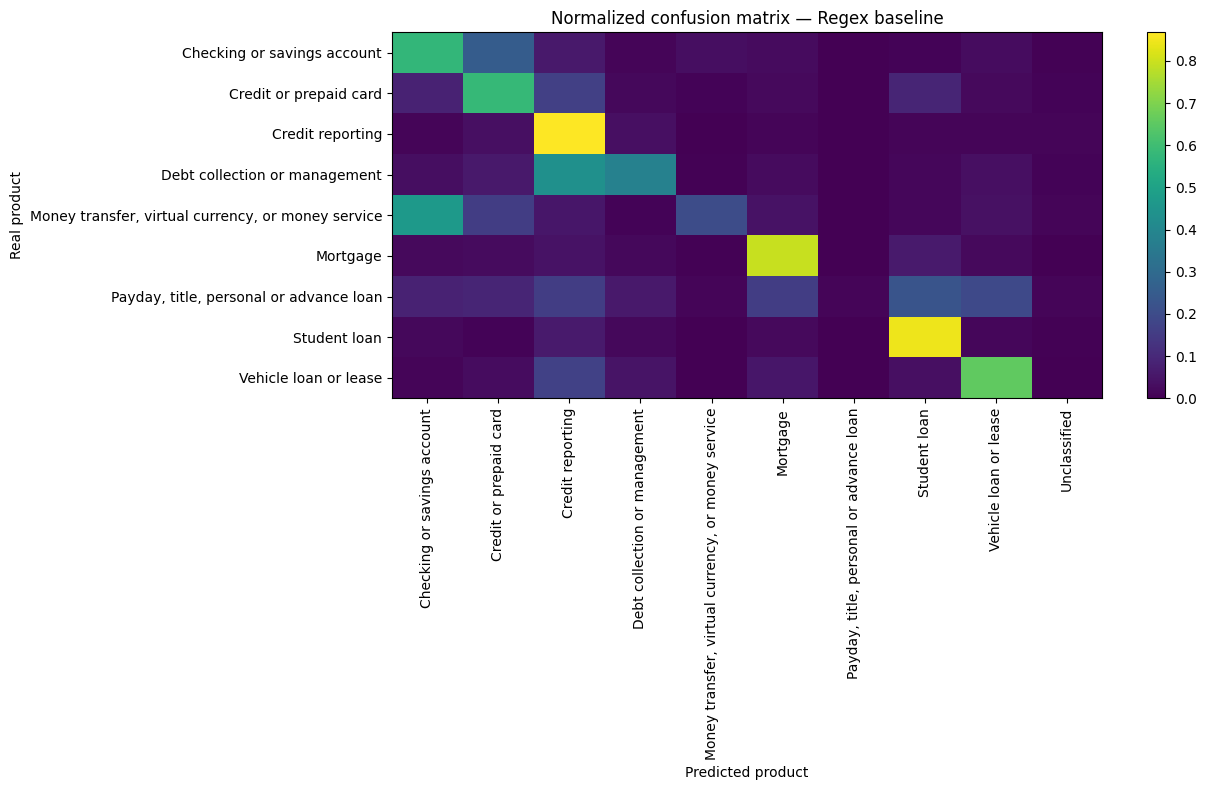

In [7]:
confusion_percentage = pd.crosstab(
    y_true,
    y_pred,
    rownames=["Real product"],
    colnames=["Predicted product"],
    normalize="index"
).round(3)

ordered_columns = (
    families
    + (
        ["Unclassified"]
        if "Unclassified" in confusion_percentage.columns
        else []
    )
)

confusion_percentage = (
    confusion_percentage
    .reindex(
        index=families,
        columns=ordered_columns,
        fill_value=0
    )
)

display(confusion_percentage)


fig, ax = plt.subplots(
    figsize=(13, 8)
)

image = ax.imshow(
    confusion_percentage.values,
    aspect="auto"
)

ax.set_xticks(
    range(len(confusion_percentage.columns))
)

ax.set_xticklabels(
    confusion_percentage.columns,
    rotation=90
)

ax.set_yticks(
    range(len(confusion_percentage.index))
)

ax.set_yticklabels(
    confusion_percentage.index
)

ax.set_xlabel("Predicted product")
ax.set_ylabel("Real product")
ax.set_title("Normalized confusion matrix — Regex baseline")

fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()